# Olist E-Commerce - 03 : Exploratory Data Analysis & Visualizations

**Author:** Diego Ospina | **Dataset:** Brazilian E-Commerce Public Dataset by Olist

> We now consume the **cleaned datasets** from `data/processed/` and run a full EDA: sales trends, by-category performance, price/review distributions, delivery behavior, geography, sellers and payments. Every figure is **saved to `images/`** (PNG) so it can be reused in a presentation or the final report.

A consistent, readable style is defined once and applied to all charts.

## 1. Setup and style

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

PROC = os.path.join('..', 'data', 'processed')
IMAGES = os.path.join('..', 'images')
os.makedirs(IMAGES, exist_ok=True)

# --- Estilo consistente para todas las figuras ---
PALETTE = sns.color_palette('viridis')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})
sns.set_theme(style='whitegrid', palette=PALETTE)
print('style ready')

style ready


## 2. Load cleaned data

In [2]:
master = pd.read_parquet(os.path.join(PROC, 'olist_master_orders.parquet'))
items  = pd.read_parquet(os.path.join(PROC, 'olist_items.parquet'))
catalog= pd.read_parquet(os.path.join(PROC, 'olist_catalog.parquet'))

print('master:', master.shape)
print('items :', items.shape)
print('catalog:', catalog.shape)

# Subconjunto operativo: solo oordenes entregadas para metricas validas
deliv = master[master['order_status'] == 'delivered'].copy()

master: (99441, 33)
items : (112650, 10)
catalog: (32951, 11)


## 3. Business overview

Quick univariate snapshot of the main business variables.

In [3]:
print('Pedidos totales:', f"{len(master):,}")
print('Pedidos entregados:', f"{(master['order_status']=='delivered').sum():,}")
print('Clientes unicos:', f"{master['customer_unique_id'].nunique():,}")
print('Ingreso productos (BRL):', f"{deliv['product_value'].sum():,.0f}")
print('Ingreso con flete (BRL):', f"{deliv['order_value'].sum():,.0f}")
print('Valor medio por pedido (BRL):', f"{deliv['order_value'].median():,.2f}")

Pedidos totales: 99,441
Pedidos entregados: 96,478
Clientes unicos: 96,096
Ingreso productos (BRL): 13,221,498
Ingreso con flete (BRL): 15,419,774
Valor medio por pedido (BRL): 105.28


## 4. Sales over time

We plot monthly sales (product value) to see the growth trend and seasonality.

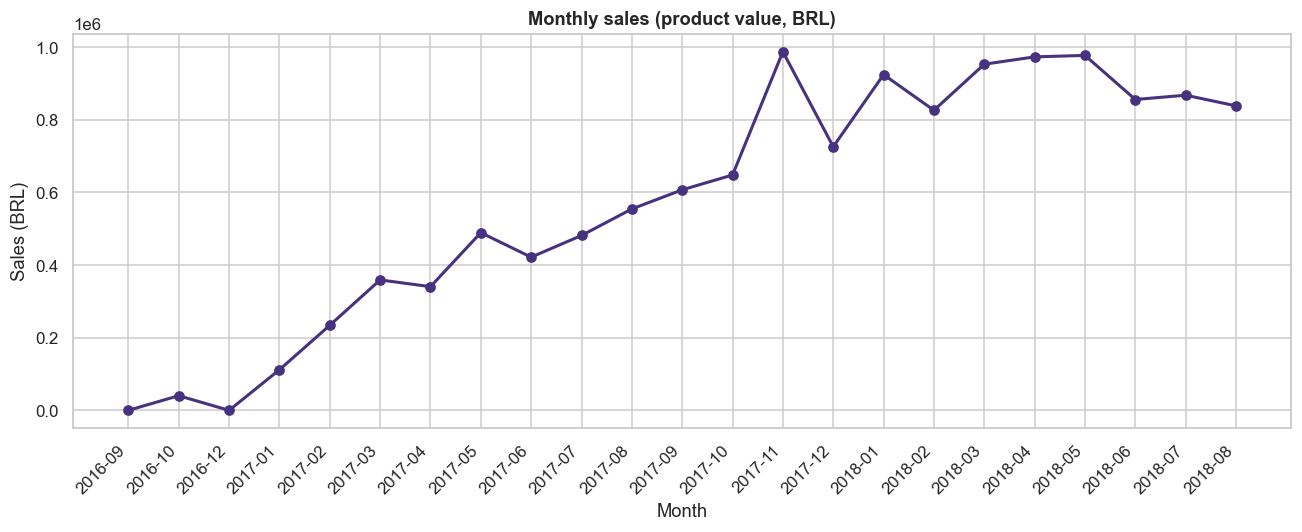

Best month:
2017-11 -> 987,765 BRL


In [4]:
monthly = (deliv.groupby('purchase_month')['product_value']
                .sum()
                .sort_index())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly.index, monthly.values, marker='o', linewidth=2, color=PALETTE[0])
ax.set_title('Monthly sales (product value, BRL)')
ax.set_xlabel('Month')
ax.set_ylabel('Sales (BRL)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES, 'EDA_monthly_sales.png'), bbox_inches='tight')
plt.show()

print('Best month:')
print(monthly.idxmax(), '->', f"{monthly.max():,.0f} BRL")

## 5. Sales by category

The top product categories drive most of the revenue. We aggregate the order value by `item_category` from the item-level table.

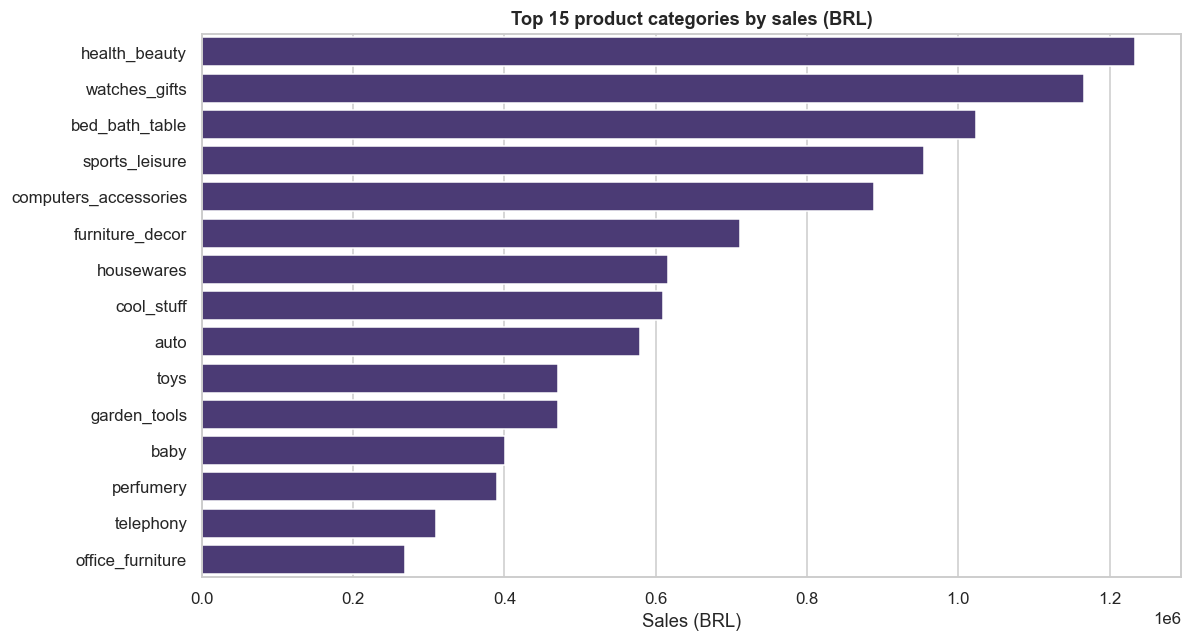

In [5]:
cat_sales = (items[items['order_id'].isin(deliv['order_id'])]
             .assign(cat=lambda d: d['item_category'].replace('not_specified', 'not_specified'))
             .groupby('item_category')['price']
             .sum()
             .sort_values(ascending=False)
             .head(15))

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x='price', y='item_category', data=cat_sales.reset_index(),
            color=PALETTE[0])
ax.set_title('Top 15 product categories by sales (BRL)')
ax.set_xlabel('Sales (BRL)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES, 'EDA_sales_by_category.png'), bbox_inches='tight')
plt.show()

## 6. Order value and price distributions

E-commerce order values are right-skewed: few large purchases, many small ones. We log-scale the histogram to make the shape readable, and show a boxplot.

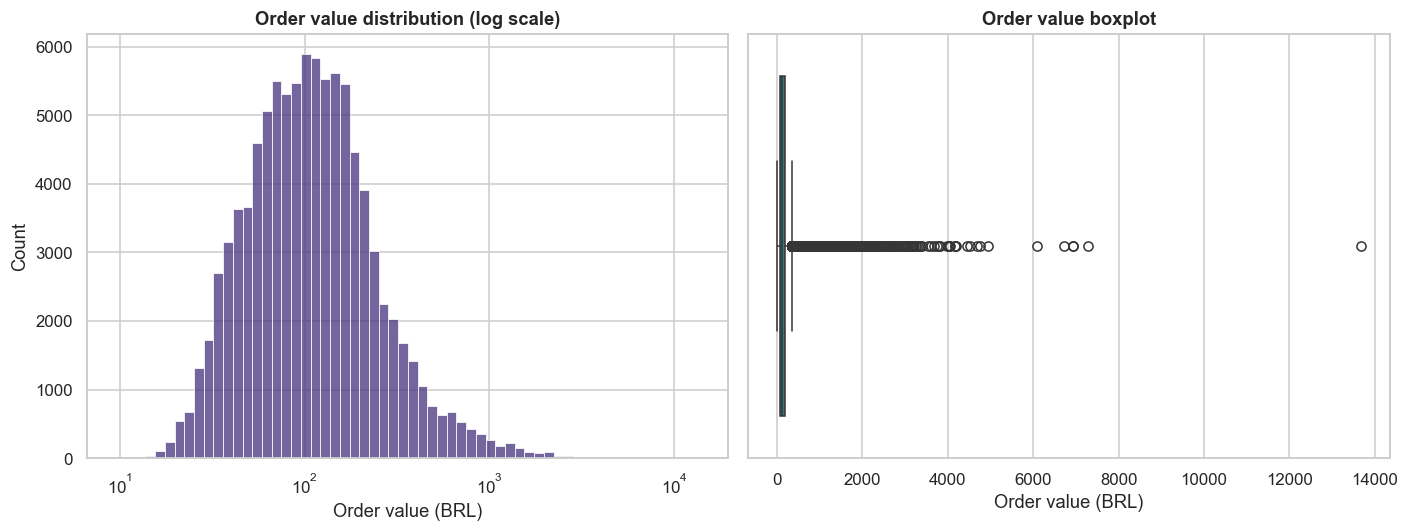

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(deliv['order_value'], bins=60, log_scale=True, ax=axes[0], color=PALETTE[0])
axes[0].set_title('Order value distribution (log scale)')
axes[0].set_xlabel('Order value (BRL)')

sns.boxplot(x=deliv['order_value'], ax=axes[1], color=PALETTE[2])
axes[1].set_title('Order value boxplot')
axes[1].set_xlabel('Order value (BRL)')

plt.tight_layout()
plt.savefig(os.path.join(IMAGES, 'EDA_order_value_dist.png'), bbox_inches='tight')
plt.show()

## 7. Delivery performance

Most delivered orders arrive early or on time. We quantify the late share and the distribution of delivery times.

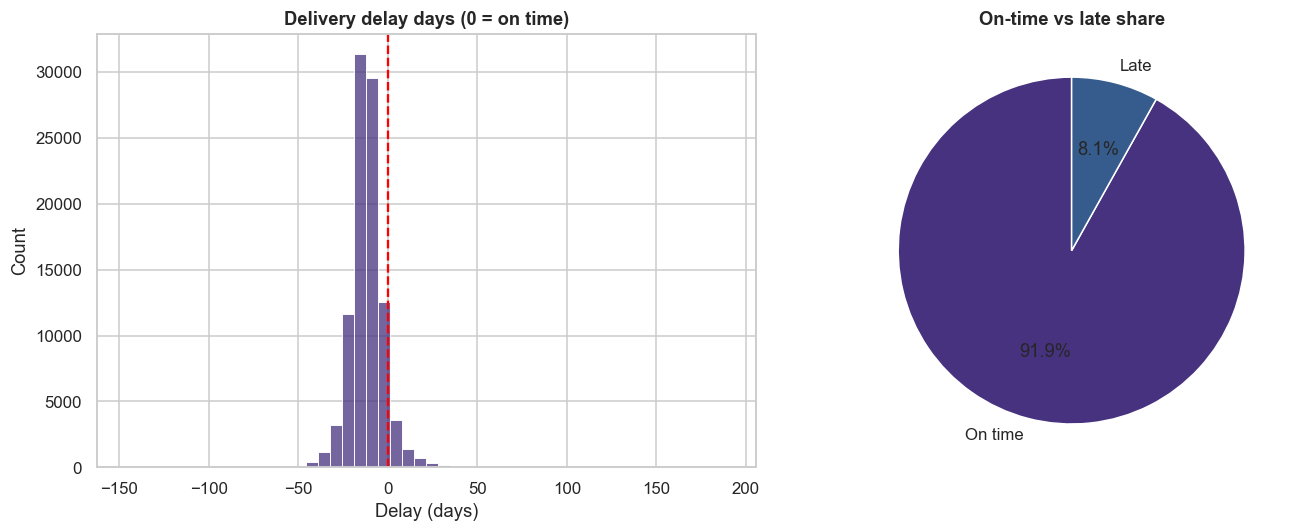

Late deliveries: 8.11%
Median delivery time (days): 10.22


In [7]:
# Porcentaje a tiempo vs tarde
status_counts = deliv['delivery_status'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(deliv['delivery_delay_days'], bins=50, ax=axes[0], color=PALETTE[0])
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Delivery delay days (0 = on time)')
axes[0].set_xlabel('Delay (days)')

axes[1].pie(status_counts, labels=status_counts.index,
           autopct='%1.1f%%', startangle=90, colors=PALETTE[:2])
axes[1].set_title('On-time vs late share')

plt.tight_layout()
plt.savefig(os.path.join(IMAGES, 'EDA_delivery.png'), bbox_inches='tight')
plt.show()

late_pct = (deliv['delivery_status']=='Late').mean()*100
print(f'Late deliveries: {late_pct:.2f}%')
print('Median delivery time (days):', round(deliv['delivery_time_days'].median(), 2))

## 8. Customer reviews

Olist reviews are discrete 1-5 scores. The distribution is bimodal and heavily positive, which is typical for e-commerce.

C:\Users\Diego\AppData\Local\Temp\ipykernel_16052\3990063199.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=scores, ax=ax, palette='viridis')


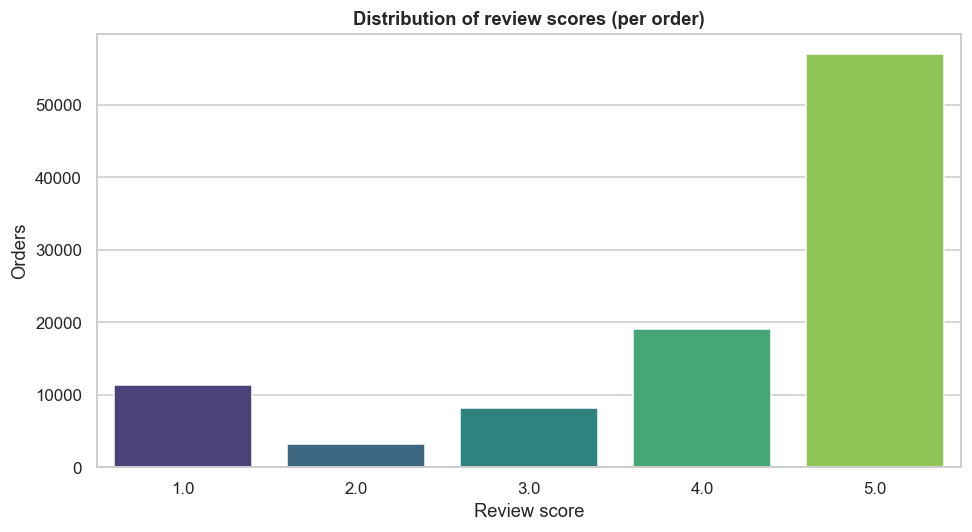

Orders with no review: 768


In [8]:
# Redondear la media por orden a un score discreto para el histograma
scores = master.dropna(subset=['review_score_mean'])['review_score_mean'].round()

fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(x=scores, ax=ax, palette='viridis')
ax.set_title('Distribution of review scores (per order)')
ax.set_xlabel('Review score')
ax.set_ylabel('Orders')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES, 'EDA_review_scores.png'), bbox_inches='tight')
plt.show()

print('Orders with no review:', master['review_score_mean'].isna().sum())

## 9. Geography - orders by state

Brazils states are the top-level geography in `customers`. We count orders per `customer_state` to show regional concentration (São Paulo dominates).

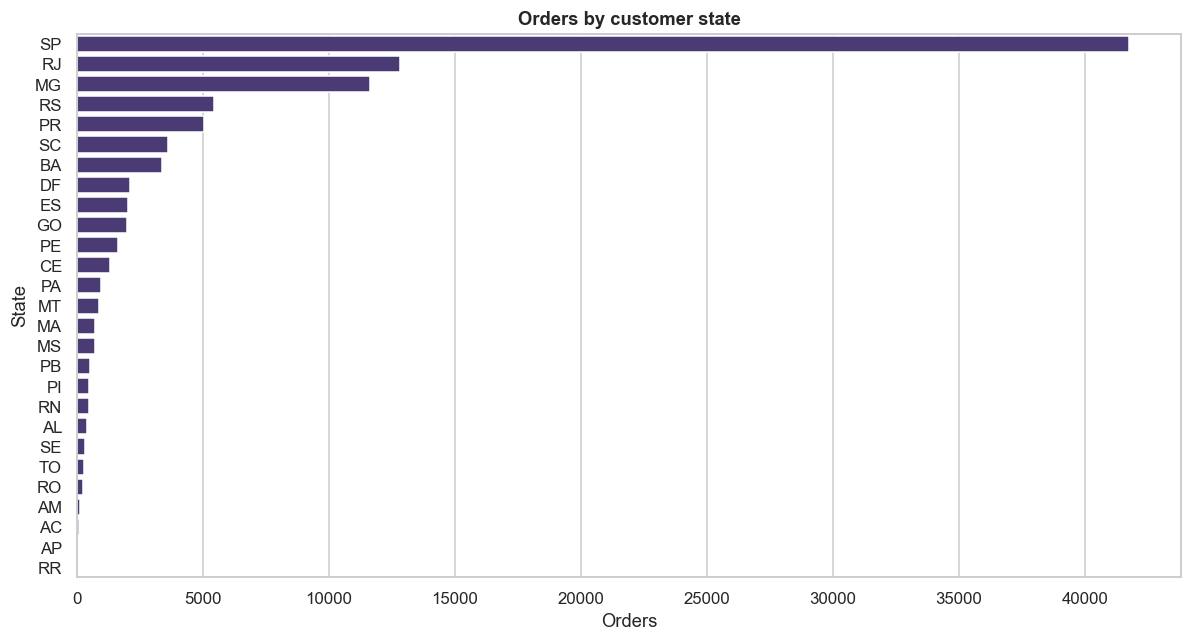

Top 5 states:
                orders
customer_state        
SP               41746
RJ               12852
MG               11635
RS                5466
PR                5045


In [9]:
state_counts = master['customer_state'].value_counts()

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=state_counts.values, y=state_counts.index, color=PALETTE[0])
ax.set_title('Orders by customer state')
ax.set_xlabel('Orders')
ax.set_ylabel('State')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES, 'EDA_orders_by_state.png'), bbox_inches='tight')
plt.show()

print('Top 5 states:')
print(state_counts.head(5).to_frame('orders'))

## 10. Payment methods
Credit card dominates, followed by Brazil's `boleto`.

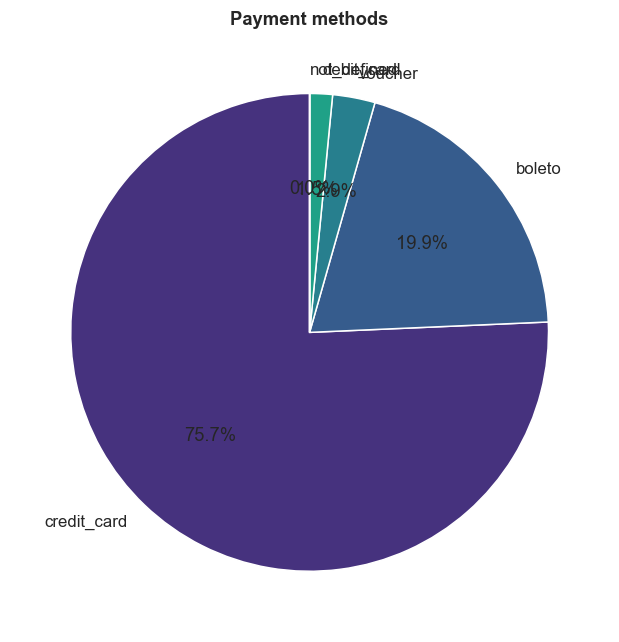

In [10]:
pay_type = master['payment_type_main'].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(pay_type.values, labels=pay_type.index, autopct='%1.1f%%',
       startangle=90, colors=PALETTE)
ax.set_title('Payment methods')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES, 'EDA_payment_methods.png'), bbox_inches='tight')
plt.show()

## 11. Correlation heatmap

We look at how the main numeric variables relate. Retain only delivered orders to avoid mixing nulls from non-delivered rows.

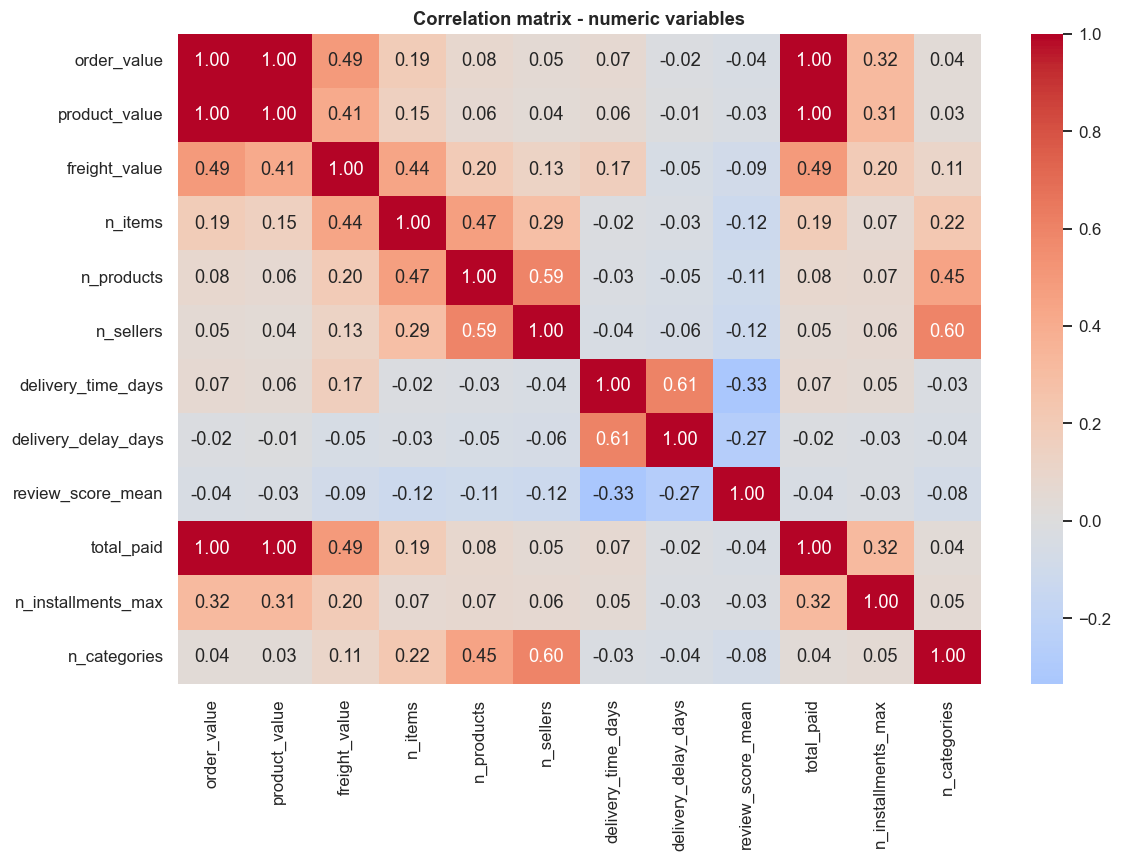

In [11]:
num_cols = ['order_value', 'product_value', 'freight_value', 'n_items',
            'n_products', 'n_sellers', 'delivery_time_days', 'delivery_delay_days',
            'review_score_mean', 'total_paid', 'n_installments_max', 'n_categories']
corr = deliv[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation matrix - numeric variables')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES, 'EDA_correlation.png'), bbox_inches='tight')
plt.show()

## 12. Takeaways

- Sales grow steadily from 2016 to 2018; the best month reaches ~988k BRL in product value.
- Health & beauty, and a handful of other categories, dominate revenue.
- Order values are highly right-skewed; most orders are small, with a long tail of large ones.
- ~92% of delivered orders arrive **on time**; late orders average only a few days of delay.
- Reviews are strongly positive overall (mode = 5), but a notable 1-star cluster reveals dissatisfaction worth investigating in the stats notebook.
- São Paulo (SP) is the top ordering state; credit card is the main payment method.
- `order_value` correlates mainly with `n_items` / `n_products`; delivery time correlates modestly with delay.

Next: **`04_statistical_analysis.ipynb`** adds formal statistical tests and deeper inference.